# 1) Текстовое описание набора данных
В качестве набора данных мы будем использовать датасет с информацией о пищевой ценности блюд из меню ресторанов быстрого питания Subway - https://www.kaggle.com/datasets/joebeachcapital/subway-nutrition

Эта задача является актуальной для анализа продуктов питания, помощи потребителям в выборе блюд в соответствии с их диетическими потребностями, а также для сравнения питательной ценности различных позиций меню.

Датасет представляет собой единый файл в формате CSV (или Excel), содержащий подробную информацию о различных продуктах, предлагаемых в Subway.

Файл содержит следующие колонки (на основе описания датасета):

- Category - Категория блюда.
- Item - Конкретный ингредиент.
- Calories - Калорийность блюда в килокалориях (ккал) - **целевой признак**.
- Total Fat (g) - Общее содержание жиров в граммах.
- Saturated Fat (g) - Содержание насыщенных жиров в граммах.
- Trans Fat (g) - Содержание трансжиров в граммах.
- Cholesterol (mg) - Содержание холестерина в миллиграммах.
- Sodium (mg) - Содержание натрия (соли) в миллиграммах.
- Carbs (g) - Общее содержание углеводов в граммах.
- Dietary Fiber (g) - Содержание пищевых волокон (клетчатки) в граммах.
- Sugars (g) - Содержание сахара в граммах.
- Protein (g) - Содержание белка в граммах.
- Weight Watchers Points - Баллы по системе Weight Watchers (система подсчета очков для контроля веса).

# 2) Импорт библиотек
Импортируем библиотеки с помощью команды import. Как правило, все команды import размещают в первой ячейке ноутбука, но мы в этом примере будем подключать все библиотеки последовательно, по мере их использования.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

# 3) Загрузка данных

In [4]:
data = pd.read_csv('SubwayMenuNutrition.csv', sep=",")

# 4) Основные характеристики датасета

In [5]:
# Первые 5 строк датасета
data.head()

,Category,Item,Calories,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Dietary Fiber (g),Sugars (g),Protein (g),Weight Watchers Pnts
0,Sandwiches,BBQ Chicken,330,4.0,1.0,0.0,50,860,50,2,16,24,323.0
1,Sandwiches,BBQ Rib,580,31.0,10.0,0.0,60,1260,54,3,18,21,587.0
2,Sandwiches,Black Forest Ham,260,4.0,1.5,0.0,30,720,42,5,8,18,251.5
3,Sandwiches,Buffalo Chicken,360,12.0,2.0,0.0,55,7710,39,3,5,24,343.0
4,Sandwiches,Chicken & Bacon Ranch,530,26.0,10.0,0.5,100,1100,41,3,6,36,510.0


In [7]:
# Размер датасета - 186 строк, 13 колонок
data.shape

(186, 13)

In [8]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 186


In [9]:
# Список колонок
data.columns

Index(['Category', 'Item', 'Calories', 'Total Fat (g)', 'Saturated Fat (g)',
       'Trans Fat (g)', 'Cholesterol (mg)', 'Sodium (mg)', 'Carbs (g)',
       'Dietary Fiber (g)', 'Sugars (g)', 'Protein (g)',
       'Weight Watchers Pnts'],
      dtype='object')

In [10]:
# Список колонок с типами данных
data.dtypes

Category                 object
Item                     object
Calories                  int64
Total Fat (g)           float64
Saturated Fat (g)       float64
Trans Fat (g)           float64
Cholesterol (mg)          int64
Sodium (mg)               int64
Carbs (g)                 int64
Dietary Fiber (g)         int64
Sugars (g)                int64
Protein (g)               int64
Weight Watchers Pnts    float64
dtype: object

In [11]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

Category - 0
Item - 0
Calories - 0
Total Fat (g) - 0
Saturated Fat (g) - 0
Trans Fat (g) - 0
Cholesterol (mg) - 0
Sodium (mg) - 0
Carbs (g) - 0
Dietary Fiber (g) - 0
Sugars (g) - 0
Protein (g) - 0
Weight Watchers Pnts - 1


In [12]:
# Основные статистические характеристки набора данных
data.describe()

,Calories,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Dietary Fiber (g),Sugars (g),Protein (g),Weight Watchers Pnts
count,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,185.000000
mean,316.612903,14.494624,4.876344,0.155914,51.424731,1028.037634,28.596774,2.844086,6.080645,19.215054,309.967568
std,235.703847,14.284559,5.175125,0.378321,48.390162,1419.398824,23.340113,2.427855,7.727029,15.179182,229.145913
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,122.500000,3.500000,1.000000,0.000000,5.000000,242.500000,10.000000,0.250000,2.250000,5.000000,121.000000
50%,290.000000,9.000000,2.500000,0.000000,45.000000,800.000000,31.500000,3.000000,5.000000,19.000000,286.500000
75%,470.000000,24.000000,8.000000,0.000000,90.000000,1427.500000,43.000000,4.000000,7.000000,30.000000,455.000000
max,1080.000000,65.000000,23.000000,2.000000,195.000000,14860.000000,114.000000,16.000000,65.000000,59.000000,1097.000000


In [14]:
# Определим уникальные значения для целевого признака
data['Calories'].unique()

array([ 330,  580,  260,  360,  530,  290,  340,  310,  430,  520,  380,
        420,  150,  230,  170,  200,  550,  490,  600,  270,  570,  280,
        450,  320,  470,  410,  780,  250,  720,  730,  190, 1080,  800,
        610,  710,  830,  680,  770,  790,  640,  820,  500,  630,  700,
        540,  750,  440,  760,  510,  590,  370,  300,  160,  120,  220,
        460,  240,  130,  140,  480,  210,  110,   50,  390,  180,   40,
         70,    0,   80,   60,   20,   45,    5,  100,   15,   35,   30,
         10])

# 5) Визуальное исследование датасета

## Диаграмма рассеяния

<Axes: xlabel='Cholesterol (mg)', ylabel='Weight Watchers Pnts'>

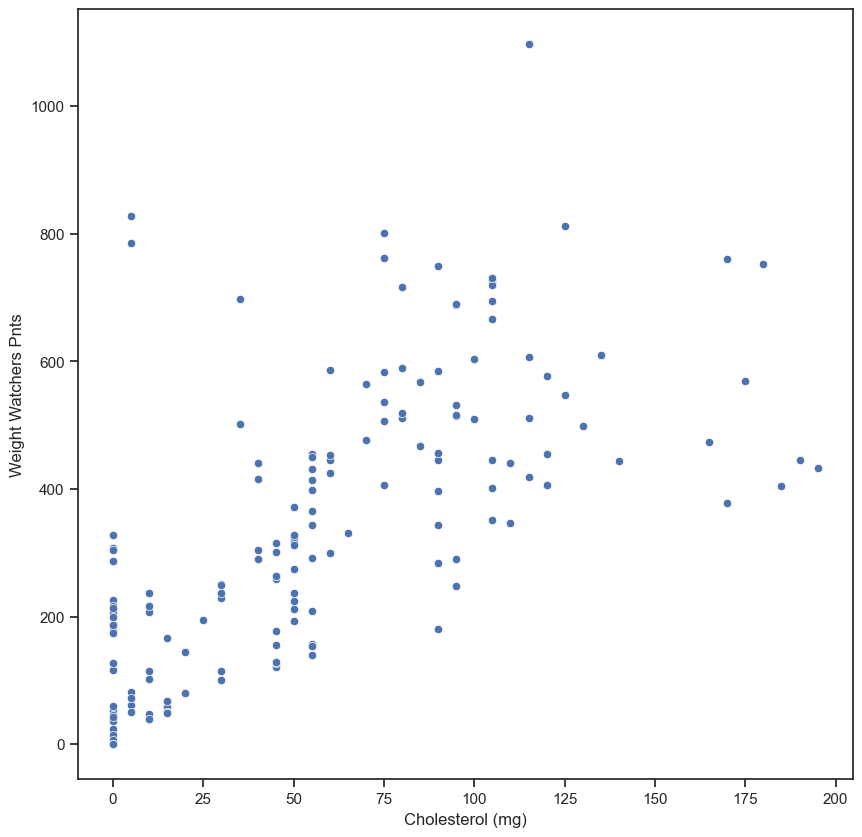

In [16]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Cholesterol (mg)', y='Weight Watchers Pnts', data=data)

<Axes: xlabel='Cholesterol (mg)', ylabel='Weight Watchers Pnts'>

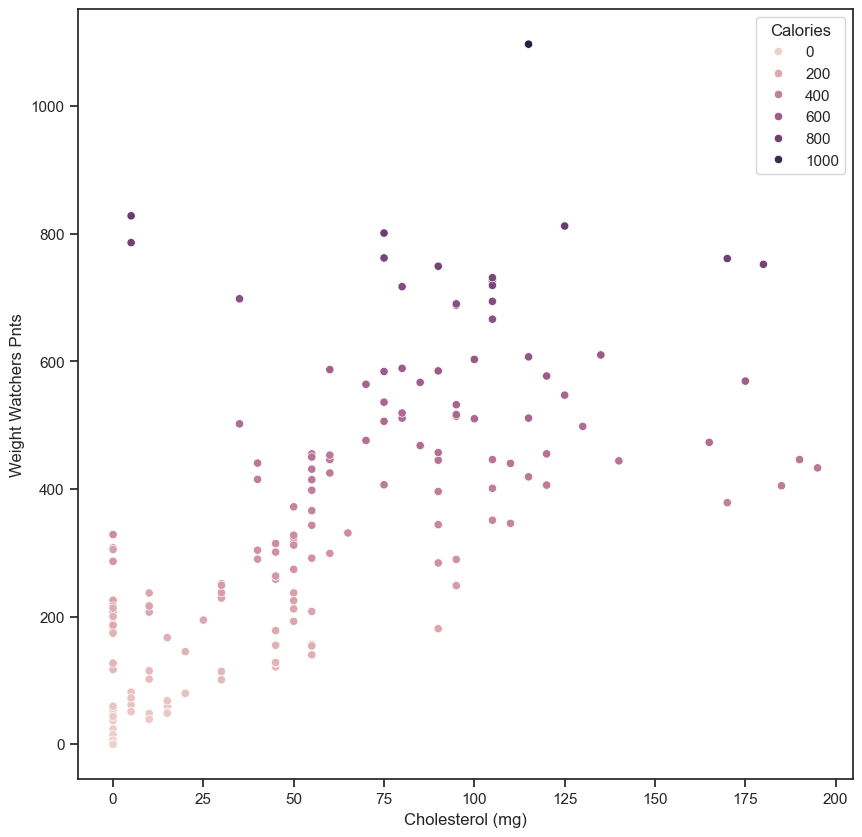

In [17]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Cholesterol (mg)', y='Weight Watchers Pnts', data=data, hue='Calories')

## Гистограмма

C:\Users\Администратоp\AppData\Local\Temp\ipykernel_10492\3567678170.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Cholesterol (mg)'])


<Axes: xlabel='Cholesterol (mg)', ylabel='Density'>

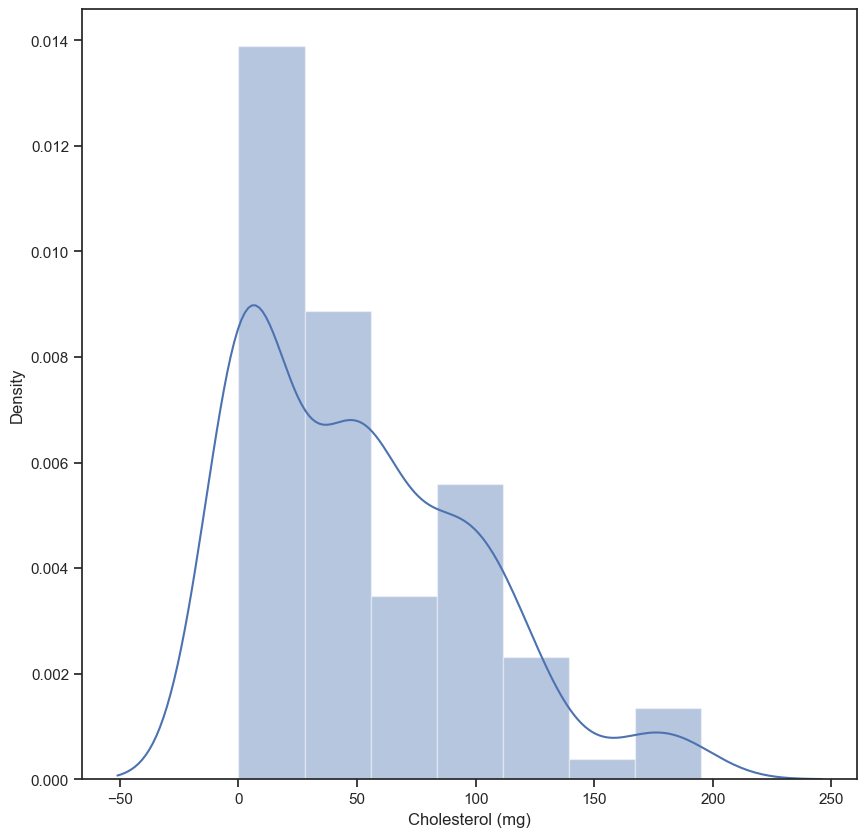

In [18]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.distplot(data['Cholesterol (mg)'])

## Парные диаграммы

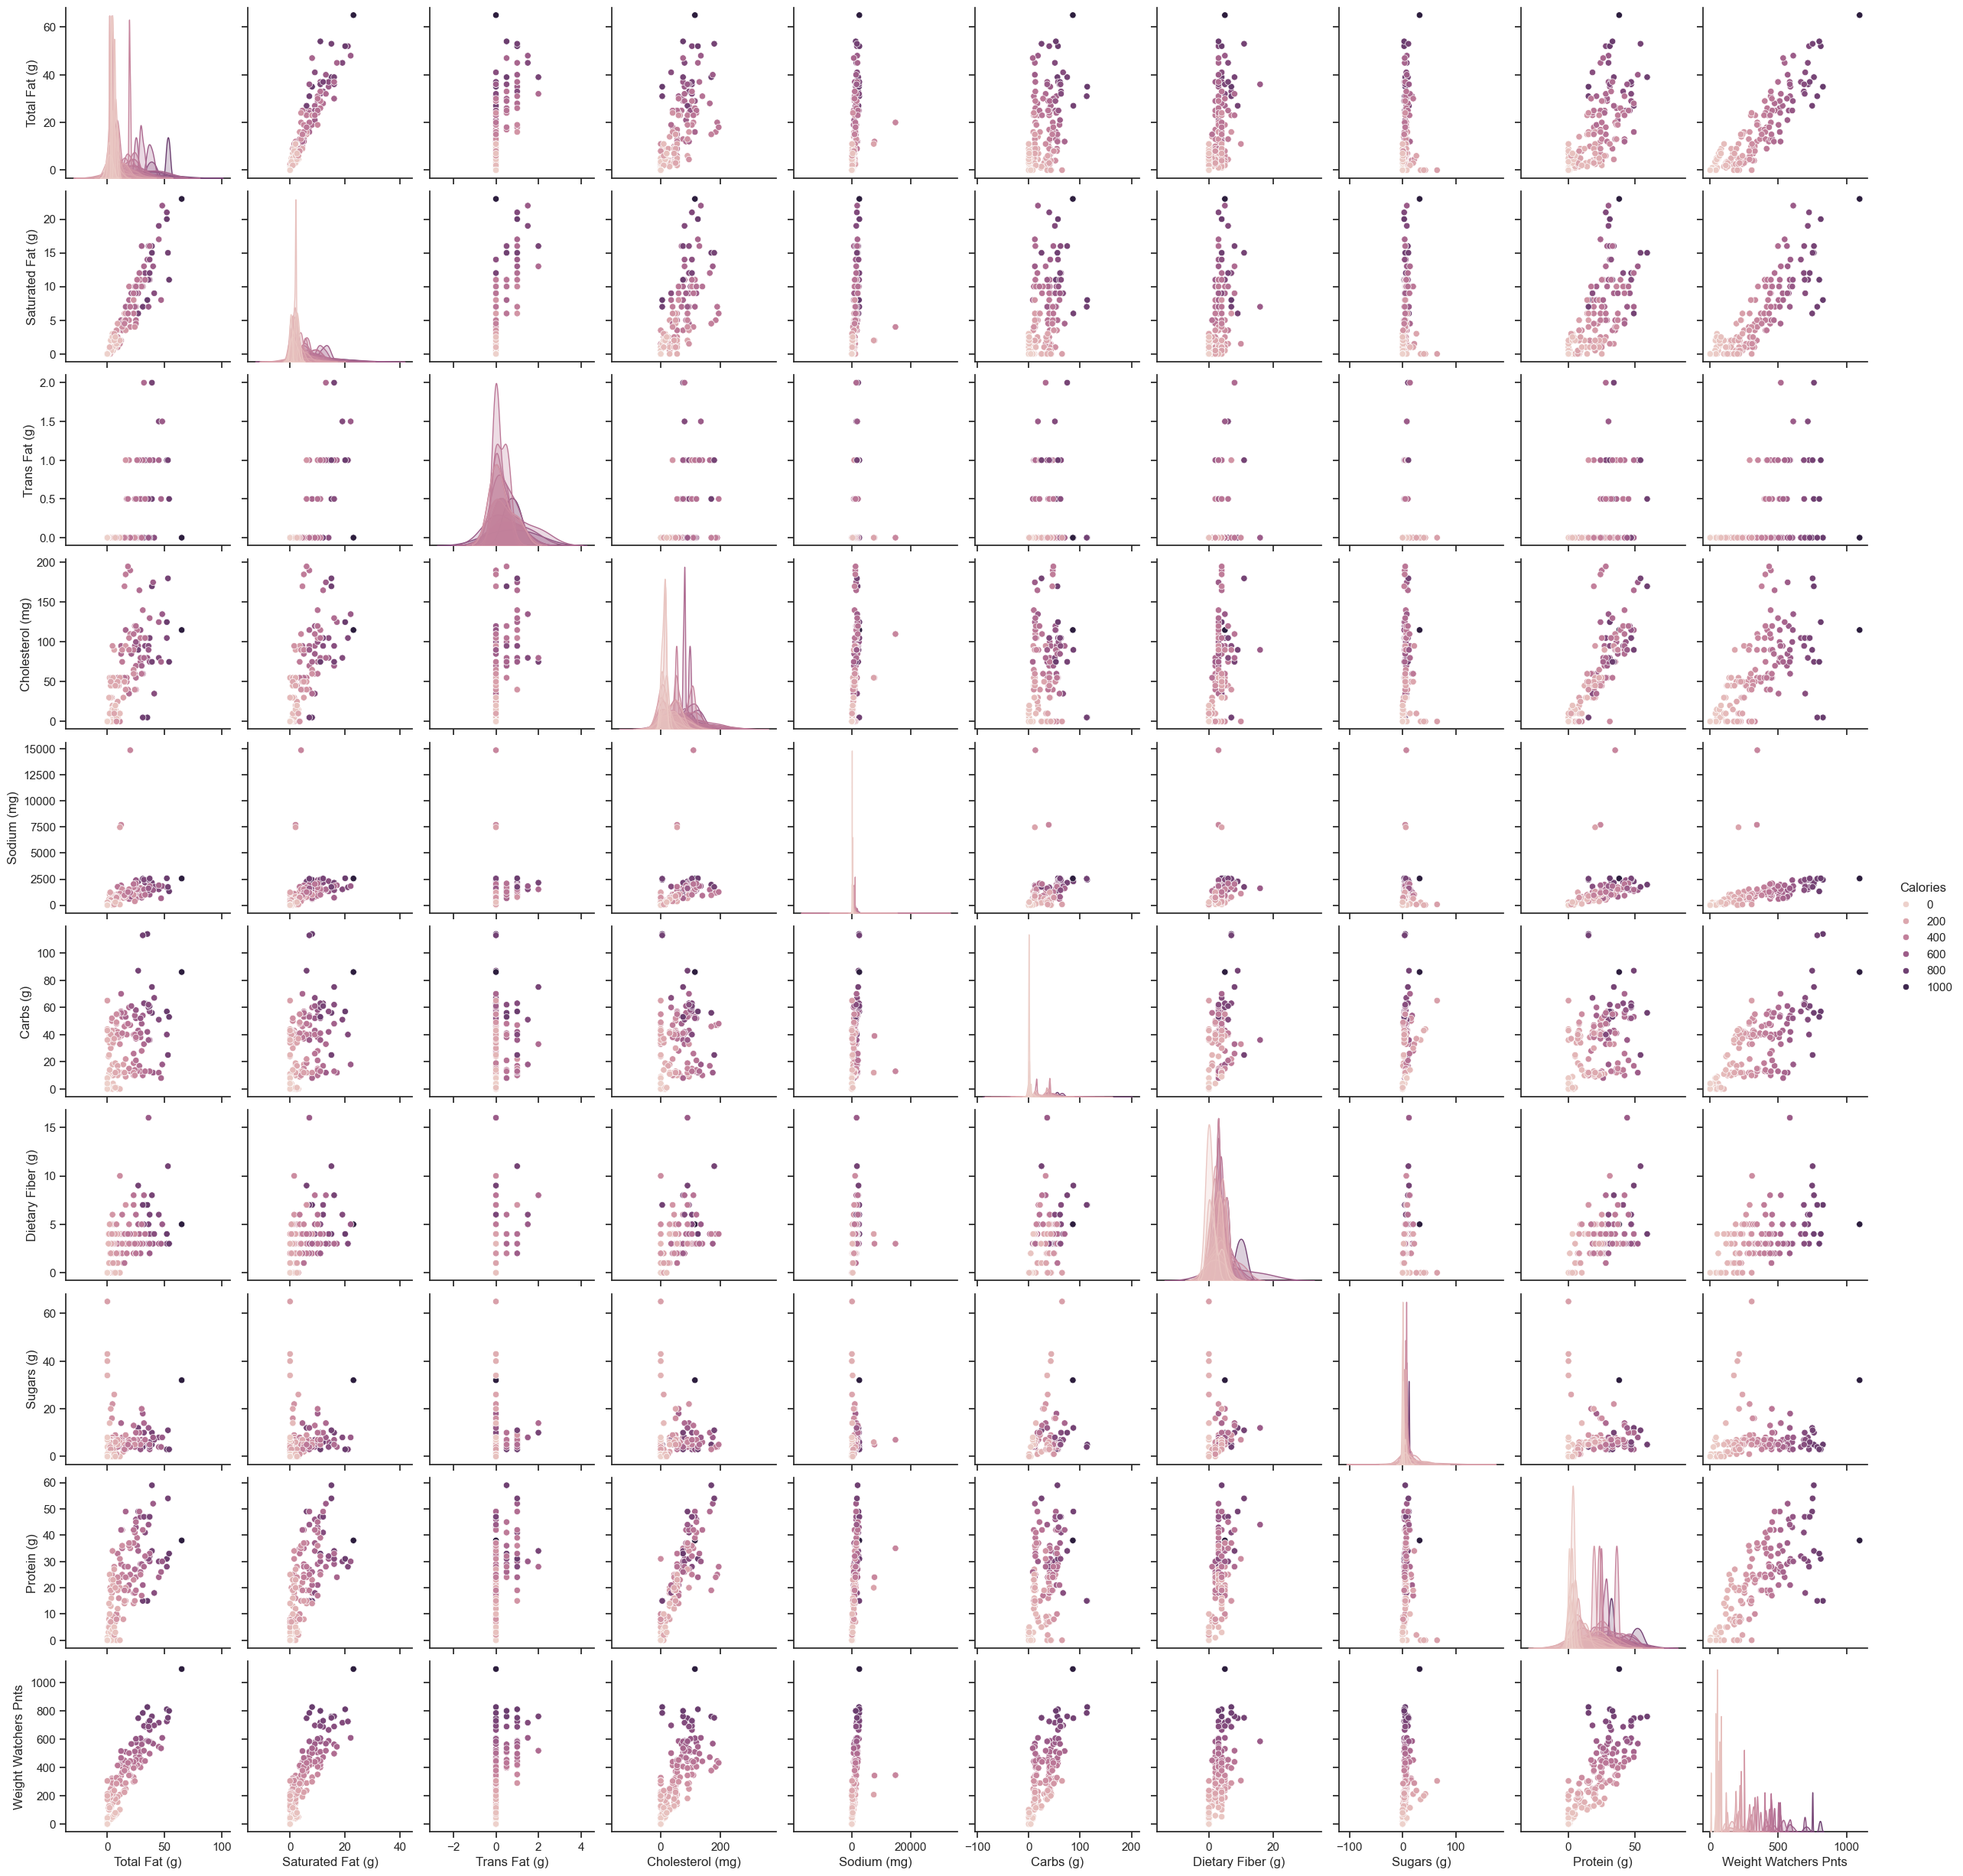

In [21]:
sns.pairplot(data, hue="Calories")

## Ящик с усами

<Axes: ylabel='Cholesterol (mg)'>

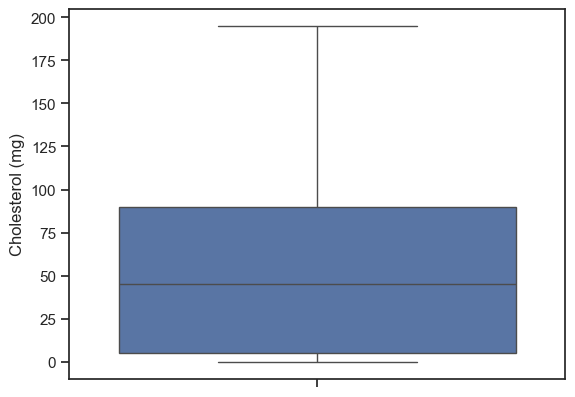

In [23]:
sns.boxplot(y=data['Cholesterol (mg)'])

# 6) Информация о корреляции признаков

In [25]:
data.select_dtypes(include=['number']).corr()

,Calories,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Dietary Fiber (g),Sugars (g),Protein (g),Weight Watchers Pnts
Calories,1.000000,0.897577,0.850184,0.461801,0.726043,0.450235,0.766869,0.634208,0.224168,0.827689,0.998639
Total Fat (g),0.897577,1.000000,0.943212,0.598795,0.710806,0.397826,0.450313,0.512526,0.099515,0.696522,0.899629
Saturated Fat (g),0.850184,0.943212,1.000000,0.684934,0.725475,0.339960,0.414093,0.438566,0.104538,0.684599,0.852971
Trans Fat (g),0.461801,0.598795,0.684934,1.000000,0.461699,0.148394,0.099594,0.303203,0.061318,0.396056,0.464874
Cholesterol (mg),0.726043,0.710806,0.725475,0.461699,1.000000,0.432572,0.316360,0.503636,0.109198,0.859304,0.706524
Sodium (mg),0.450235,0.397826,0.339960,0.148394,0.432572,1.000000,0.280455,0.340312,0.064715,0.480094,0.438521
Carbs (g),0.766869,0.450313,0.414093,0.099594,0.316360,0.280455,1.000000,0.499873,0.357085,0.504514,0.773451
Dietary Fiber (g),0.634208,0.512526,0.438566,0.303203,0.503636,0.340312,0.499873,1.000000,0.177011,0.669608,0.619572
Sugars (g),0.224168,0.099515,0.104538,0.061318,0.109198,0.064715,0.357085,0.177011,1.000000,0.146082,0.252528
Protein (g),0.827689,0.696522,0.684599,0.396056,0.859304,0.480094,0.504514,0.669608,0.146082,1.000000,0.802227


<Axes: >

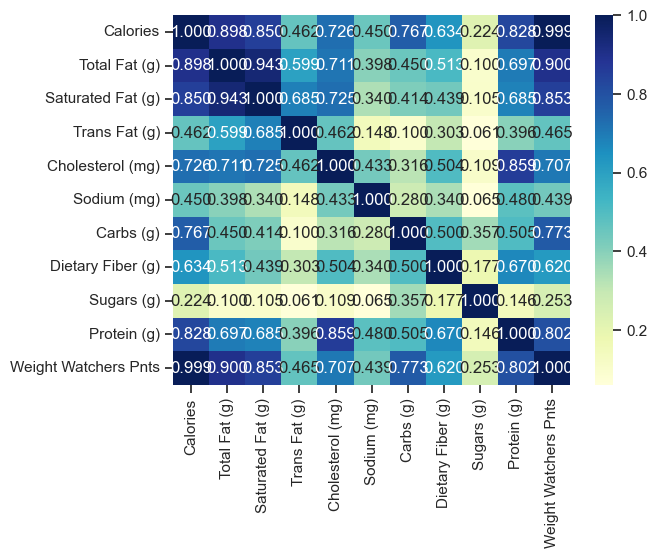

In [28]:
sns.heatmap(data.select_dtypes(include=['number']).corr(), cmap='YlGnBu', annot=True, fmt='.3f')